In [1]:
print('Hello, World!')

Hello, World!


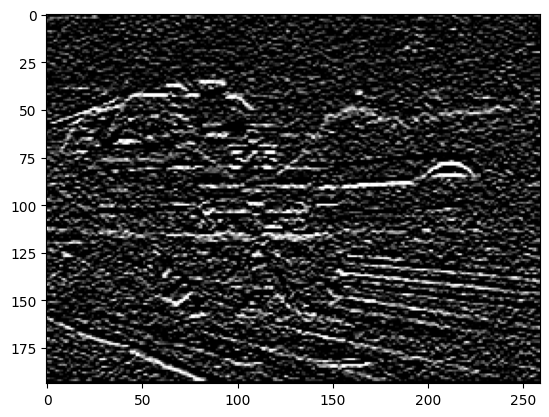

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('images.jpg', cv2.IMREAD_GRAYSCALE)
kernel = np.array([[1,2,1], [0,0,0], [-1,-2,-1]])

convolved_image = cv2.filter2D(image, -1, kernel)

plt.imshow(convolved_image, cmap='gray')
plt.show()

In [3]:
def box_filt(n):
    """
    Creates a box filter kernel of size n x n.
    """
    if n <= 0 or n % 2 == 0:
        raise ValueError("Window size must be a positive odd integer.")
    # Create a kernel with all elements equal to
    # 1/(n*n)
    kernel = np.ones((n, n), np.float32) / (n * n)
    return kernel

In [5]:

import copy


def apply_filters(image_input, box, filt_size):
    pad_size = int(np.ceil(filt_size/2))
    image_padded = np.pad(image_input,
    pad_width=((pad_size,pad_size),(pad_size, pad_size)), mode='symmetric')
    image_box = copy.deepcopy(image_input)
    for i in range(image_input.shape[0]):
        for j in range(image_input.shape[1]):
            # image_input[i,j] = 0
            patch_curr = image_padded[i:i + filt_size, j:j + filt_size]
            results_box = box * patch_curr
            image_box[i,j] = np.sum(results_box)
    return image_box

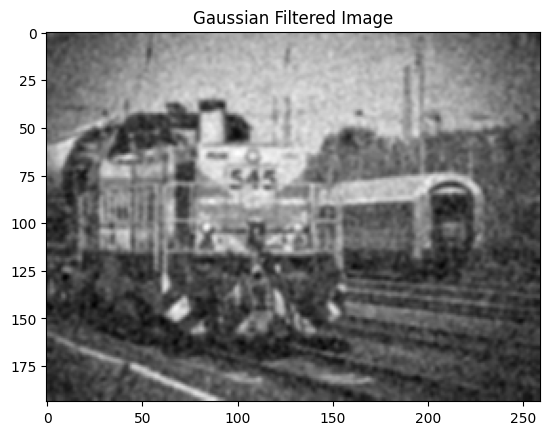

In [6]:
gaussian_filtered_image = cv2.GaussianBlur(image, (5, 5), 0)

plt.imshow(gaussian_filtered_image, cmap='gray')
plt.title('Gaussian Filtered Image')
plt.show()

In [7]:
def gauss_filt(n, sigma=1.0):
    """
        Creates a Gaussian filter kernel of size n x n
    with standard deviation sigma.
"""
    if n <= 0 or n % 2 == 0:
        raise ValueError("Window size must be a positive odd integer.")
# Create a Gaussian kernel
    ax = np.linspace(-(n - 1) / 2., (n - 1) / 2.,n)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-0.5 * (np.square(xx) +
    np.square(yy)) / np.square(sigma))
# Normalize the kernel
    kernel = kernel / np.sum(kernel)
    return kernel

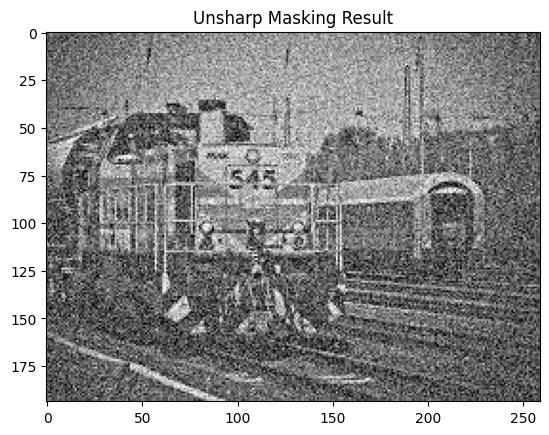

In [8]:
blurred = cv2.GaussianBlur(image, (9, 9), 10)
unsharp_image = cv2.addWeighted(image, 1.5, blurred, -0.5, 0)

plt.imshow(unsharp_image, cmap='gray')
plt.title('Unsharp Masking Result')
plt.show()

In [9]:
import copy

import cv2
import numpy as np
import matplotlib.pyplot as plt



def box_filt(n):
    """
    Creates a box filter kernel of size n x n.
    """
    if n <= 0 or n % 2 == 0:
        raise ValueError("Window size must be a positive odd integer.")
# Create a kernel with all elements equal to
    1/(n*n)
    kernel = np.ones((n, n), np.float32) / (n * n)
    return kernel
def apply_filters(image_input, box, filt_size):
    pad_size = int(np.ceil(filt_size/2))
# pad_size = pad_size.astype('uint8')
# print(pad_size.dtype)
    image_padded = np.pad(image_input,
    pad_width=((pad_size,pad_size),(pad_size, pad_size)), mode='symmetric')
    image_box = copy.deepcopy(image_input)
    row, column = image_input.shape
    for i in range(row):
        for j in range(column):
            # image_input[i,j] = 0
            patch_curr = image_padded[i:i + filt_size, j:j + filt_size]
            results_box = box * patch_curr
    image_box[i,j] = np.sum(results_box)
    return image_box
filt_size = 5
k = 2

In [ ]:
image_input = cv2.imread('images.jpg', 0).astype('float32')/255
box = box_filt(filt_size)
image_blur = apply_filters(image_input, box, filt_size)
image_diff = image_input - image_blur
image_sharp = image_input+k*image_diff
cv2.imshow('sharpen image', image_sharp)
cv2.waitKey(-1)

-1